# Notebook 2: Feature Engineering
## Real-Time Air Quality Monitoring Agent

**Purpose:** This notebook derives new informative features from the cleaned dataset
to improve model performance.  Feature engineering transforms raw sensor readings
into higher-level representations that capture domain knowledge about air pollution.

**Prerequisites:** Run `01_data_understanding_preprocessing.ipynb` first.

**Key outputs:** `data/air_quality_features.csv` — enriched feature set for modelling.

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Imports
# pandas and numpy handle data manipulation.
# scipy.stats provides statistical measures like skewness.
# sklearn.decomposition provides PCA for dimensionality reduction later.
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Load the cleaned dataset produced by Notebook 1
# parse_dates ensures the Date column is read as datetime, not a plain string.
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv('data/air_quality_clean.csv', parse_dates=['Date'])
print(f'✅ Loaded {df.shape[0]} rows × {df.shape[1]} columns')
df.head(3)

✅ Loaded 5000 rows × 23 columns


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Xylene,AQI,Year,Month,Day,DayOfWeek,WeekOfYear,Season,City_enc,Season_enc
0,Lucknow,2023-09-10,43.865377,17.051409,3.671313,2.292816,20.378562,16.862121,3.321278,16.548923,...,0.892300,27.80,2023,9,10,6,36,Monsoon,7,1
1,Mumbai,2017-05-10,22.735846,19.146266,1.929438,3.813992,72.196202,18.977122,3.421522,29.120792,...,1.986239,20.41,2017,5,10,2,19,Spring,8,2
2,Kolkata,2018-07-18,34.724831,42.043647,17.131293,5.266993,34.498422,8.470878,0.940792,31.663269,...,5.420781,28.45,2018,7,18,2,29,Summer,6,3


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — CPCB Official AQI Calculation
#
# India's Central Pollution Control Board (CPCB) calculates AQI using
# sub-indices for each pollutant.  The overall AQI equals the MAXIMUM
# sub-index, meaning a single very-bad pollutant drives the overall score.
#
# Formula:  Ip = [(IHi - ILo) / (BPHi - BPLo)] × (Cp - BPLo) + ILo
#   Ip   = sub-index for pollutant p
#   Cp   = observed concentration
#   BPHi, BPLo = breakpoint concentrations
#   IHi, ILo   = AQI index values at breakpoints
# ─────────────────────────────────────────────────────────────────────────────
def cpcb_subindex(Cp, breakpoints):
    """
    Compute CPCB AQI sub-index for a single pollutant concentration.
    breakpoints: list of (BPLo, BPHi, ILo, IHi) tuples in ascending order.
    """
    for (BPLo, BPHi, ILo, IHi) in breakpoints:
        if BPLo <= Cp <= BPHi:
            return ((IHi - ILo) / (BPHi - BPLo)) * (Cp - BPLo) + ILo
    return 500  # Beyond worst breakpoint → maximum AQI

# CPCB breakpoints for PM2.5 (µg/m³)
PM25_BP = [
    (0,  30,   0,  50),
    (30,  60,  51, 100),
    (60,  90, 101, 200),
    (90, 120, 201, 300),
    (120,250, 301, 400),
    (250,500, 401, 500),
]

# CPCB breakpoints for PM10 (µg/m³)
PM10_BP = [
    (0,   50,   0,  50),
    (50,  100,  51, 100),
    (100, 250, 101, 200),
    (250, 350, 201, 300),
    (350, 430, 301, 400),
    (430, 600, 401, 500),
]

# Compute sub-indices and take the maximum as the final AQI
df['AQI_PM25_subindex'] = df['PM2.5'].apply(lambda x: cpcb_subindex(x, PM25_BP))
df['AQI_PM10_subindex'] = df['PM10'].apply(lambda x: cpcb_subindex(x, PM10_BP))

# Official AQI = max sub-index (we use PM2.5 and PM10 as primary indicators)
df['AQI_Official'] = df[['AQI_PM25_subindex', 'AQI_PM10_subindex']].max(axis=1).round(1)

print('✅ Official CPCB AQI sub-indices computed')
print(df[['PM2.5','AQI_PM25_subindex','PM10','AQI_PM10_subindex','AQI_Official']].head(5))

✅ Official CPCB AQI sub-indices computed
       PM2.5  AQI_PM25_subindex       PM10  AQI_PM10_subindex  AQI_Official
0  43.865377          73.646783  17.051409          17.051409          73.6
1  22.735846          37.893077  19.146266          19.146266          37.9
2  34.724831          58.717223  42.043647          42.043647          58.7
3  30.301258          51.492055  14.728721          14.728721          51.5
4  32.306400          54.767120  33.688237          33.688237          54.8


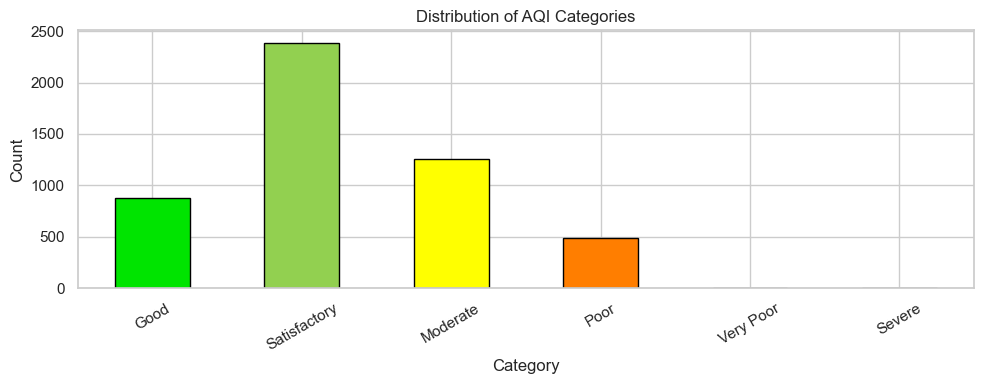

AQI_Category
Good             875.0
Satisfactory    2388.0
Moderate        1253.0
Poor             484.0
Very Poor          NaN
Severe             NaN
Name: count, dtype: float64


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — AQI Category (Target Label for supervised tasks)
#
# CPCB defines six AQI categories.  This categorical label will be used for
# classification tasks and for the health advisory system.
# ─────────────────────────────────────────────────────────────────────────────
def aqi_category(aqi):
    """Map a numeric AQI to the CPCB descriptive category."""
    if aqi <= 50:   return 'Good'
    elif aqi <= 100: return 'Satisfactory'
    elif aqi <= 200: return 'Moderate'
    elif aqi <= 300: return 'Poor'
    elif aqi <= 400: return 'Very Poor'
    else:            return 'Severe'

df['AQI_Category'] = df['AQI_Official'].apply(aqi_category)

# Ordinal encoding: Good=0 … Severe=5 (useful for ordered classification)
cat_order = {'Good': 0, 'Satisfactory': 1, 'Moderate': 2,
             'Poor': 3, 'Very Poor': 4, 'Severe': 5}
df['AQI_Category_Code'] = df['AQI_Category'].map(cat_order)

# Distribution of AQI categories
cat_counts = df['AQI_Category'].value_counts().reindex(
    ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe'])

colors = ['#00e400','#92d050','#ffff00','#ff7e00','#ff0000','#7e0023']
plt.figure(figsize=(10, 4))
cat_counts.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Distribution of AQI Categories')
plt.xlabel('Category'); plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print(cat_counts)

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Pollution Ratio Features
#
# Ratios between pollutants capture source characteristics:
#  • NO2/NOx ratio → photochemical activity and traffic influence
#  • PM2.5/PM10  → fine vs coarse particle fraction (higher = more combustion)
#  • SO2/NO2     → industrial vs vehicular pollution source signature
# ─────────────────────────────────────────────────────────────────────────────
EPSILON = 1e-6  # Prevent division by zero

df['NO2_NOx_ratio']  = df['NO2']   / (df['NOx']  + EPSILON)
df['PM25_PM10_ratio']= df['PM2.5'] / (df['PM10'] + EPSILON)
df['SO2_NO2_ratio']  = df['SO2']   / (df['NO2']  + EPSILON)
df['CO_NO2_ratio']   = df['CO']    / (df['NO2']  + EPSILON)

# Clip ratios to [0, 1] where physically meaningful (PM ratio must be ≤1)
df['PM25_PM10_ratio'] = df['PM25_PM10_ratio'].clip(0, 1)

print('✅ Pollution ratio features computed')
df[['NO2_NOx_ratio','PM25_PM10_ratio','SO2_NO2_ratio','CO_NO2_ratio']].describe().round(3)

✅ Pollution ratio features computed


,NO2_NOx_ratio,PM25_PM10_ratio,SO2_NO2_ratio,CO_NO2_ratio
count,5000.000,5000.000,5000.000,5000.000
mean,44.257,0.608,3.746,0.462
std,2426.566,0.329,45.555,6.888
min,0.000,0.032,0.000,0.000
25%,0.257,0.301,0.189,0.020
50%,0.707,0.590,0.516,0.052
75%,1.981,1.000,1.362,0.142
max,170241.795,1.000,2394.660,286.279


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Rolling Window Features (7-day and 30-day)
#
# Rolling statistics capture short-term and medium-term pollution trends.
# A 7-day rolling mean shows weekly persistence; 30-day shows monthly trends.
# We sort by City and Date to ensure the window is applied chronologically.
# min_periods=1 prevents NaN when fewer than window rows exist.
# ─────────────────────────────────────────────────────────────────────────────
df = df.sort_values(['City', 'Date']).reset_index(drop=True)

for window, label in [(7, '7d'), (30, '30d')]:
    grp = df.groupby('City')['AQI_Official']
    df[f'AQI_rolling_mean_{label}'] = grp.transform(
        lambda x: x.rolling(window, min_periods=1).mean()).round(2)
    df[f'AQI_rolling_std_{label}']  = grp.transform(
        lambda x: x.rolling(window, min_periods=1).std()).fillna(0).round(2)

# Day-over-day AQI change to capture sudden spikes
df['AQI_lag1']   = df.groupby('City')['AQI_Official'].shift(1).fillna(method='bfill')
df['AQI_change'] = (df['AQI_Official'] - df['AQI_lag1']).round(2)

print('✅ Rolling window and lag features added')
df[['City','Date','AQI_Official','AQI_rolling_mean_7d',
    'AQI_rolling_mean_30d','AQI_change']].head(10)

✅ Rolling window and lag features added


,City,Date,AQI_Official,AQI_rolling_mean_7d,AQI_rolling_mean_30d,AQI_change
0,Ahmedabad,2015-01-10,78.5,78.50,78.50,0.0
1,Ahmedabad,2015-01-14,45.9,62.20,62.20,-32.6
2,Ahmedabad,2015-01-22,135.5,86.63,86.63,89.6
3,Ahmedabad,2015-01-25,42.4,75.58,75.58,-93.1
4,Ahmedabad,2015-02-08,201.1,100.68,100.68,158.7
5,Ahmedabad,2015-02-10,71.7,95.85,95.85,-129.4
6,Ahmedabad,2015-02-19,25.2,85.76,85.76,-46.5
7,Ahmedabad,2015-02-20,37.7,79.93,79.75,12.5
8,Ahmedabad,2015-02-26,92.2,86.54,81.13,54.5
9,Ahmedabad,2015-03-02,66.6,76.70,79.68,-25.6


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Composite Pollution Index
#
# A single score that combines multiple pollutants weighted by their
# health impact.  PM2.5 has the highest weight because it penetrates
# deepest into the lungs (PM2.5 → alveoli; PM10 → upper airways).
# ─────────────────────────────────────────────────────────────────────────────
# Normalise key pollutants to 0-1 range for fair combination
from sklearn.preprocessing import MinMaxScaler
composite_cols = ['PM2.5', 'PM10', 'NO2', 'SO2', 'O3', 'CO']
mms = MinMaxScaler()
norm = pd.DataFrame(mms.fit_transform(df[composite_cols]),
                    columns=composite_cols)

# Health-impact weights (must sum to 1)
weights = {'PM2.5': 0.35, 'PM10': 0.20, 'NO2': 0.15,
           'SO2':   0.15, 'O3':   0.10, 'CO':  0.05}

df['Pollution_Index'] = sum(norm[col] * w for col, w in weights.items()).round(4)

print('✅ Composite Pollution Index computed (0–1 scale)')
print(df['Pollution_Index'].describe().round(4))

✅ Composite Pollution Index computed (0–1 scale)
count    5000.0000
mean        0.3445
std         0.1280
min         0.0617
25%         0.2492
50%         0.3288
75%         0.4250
max         0.8837
Name: Pollution_Index, dtype: float64


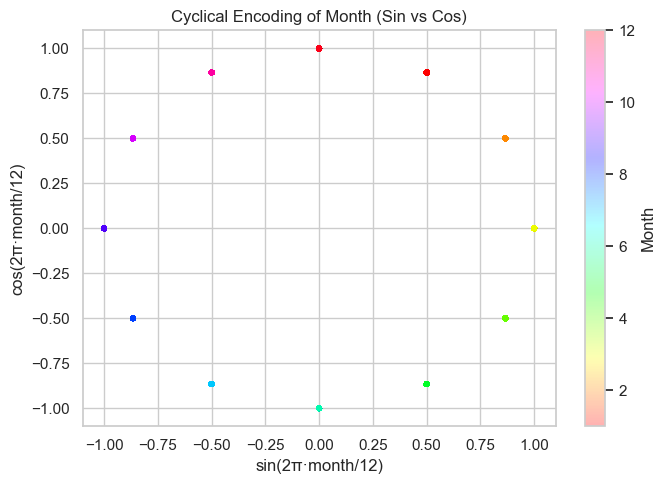

✅ Cyclical temporal features added


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Cyclical Encoding of Month and DayOfWeek
#
# Month (1–12) and DayOfWeek (0–6) are cyclical — December is adjacent to
# January, and Sunday is adjacent to Monday.  Representing them as
# sine/cosine pairs preserves this circular structure for the model.
# ─────────────────────────────────────────────────────────────────────────────
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
df['DOW_sin']   = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['DOW_cos']   = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

# Visualise cyclical encoding for Month
plt.figure(figsize=(7, 5))
sc = plt.scatter(df['Month_sin'], df['Month_cos'],
                 c=df['Month'], cmap='hsv', alpha=0.3, s=10)
plt.colorbar(sc, label='Month')
plt.title('Cyclical Encoding of Month (Sin vs Cos)')
plt.xlabel('sin(2π·month/12)'); plt.ylabel('cos(2π·month/12)')
plt.tight_layout()
plt.show()
print('✅ Cyclical temporal features added')

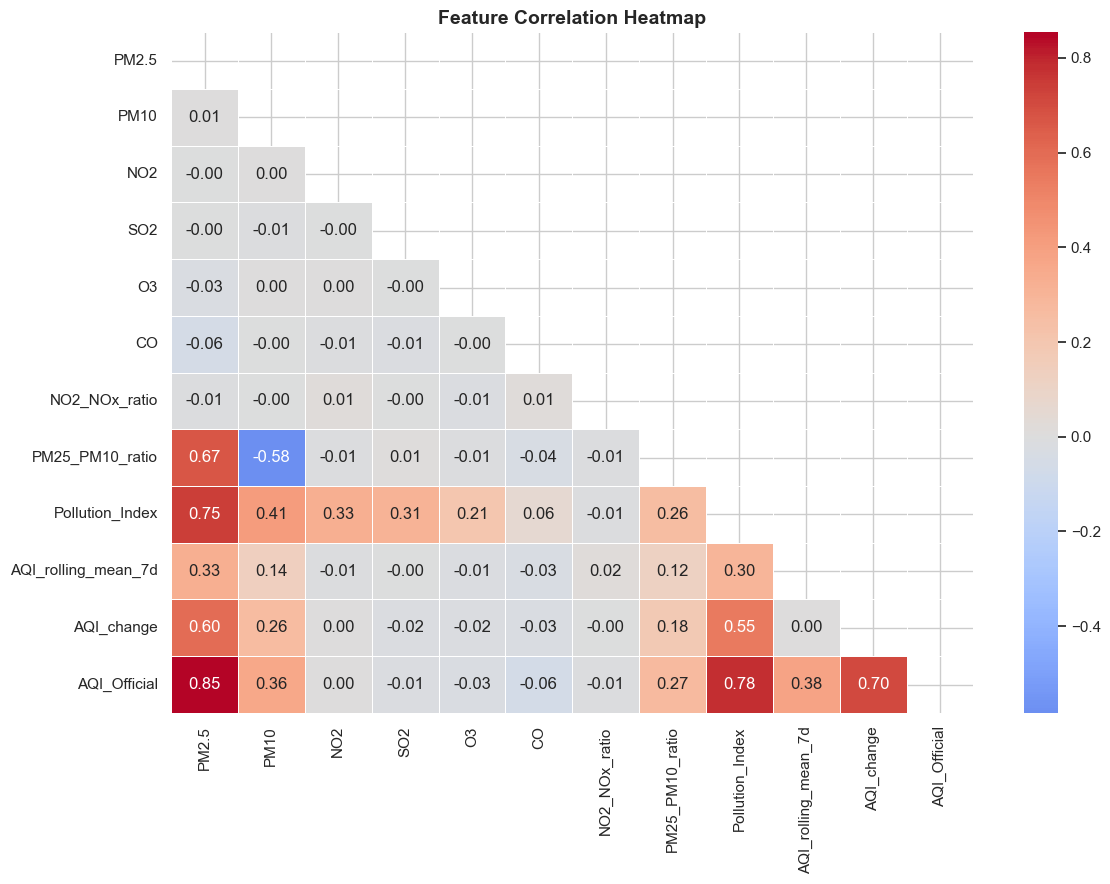

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Feature Correlation Analysis
#
# The correlation heatmap shows linear relationships between features.
# Strong correlations (|r| > 0.7) indicate possible redundancy; we note
# these for removal in modelling steps to reduce multicollinearity.
# ─────────────────────────────────────────────────────────────────────────────
feature_cols = ['PM2.5','PM10','NO2','SO2','O3','CO',
                'NO2_NOx_ratio','PM25_PM10_ratio','Pollution_Index',
                'AQI_rolling_mean_7d','AQI_change','AQI_Official']

corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show lower triangle only
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Save engineered feature dataset
#
# This enriched file is the primary input for Notebooks 3, 4, and 5.
# We also print the final feature list for documentation.
# ─────────────────────────────────────────────────────────────────────────────
df.to_csv('data/air_quality_features.csv', index=False)

numeric_features = df.select_dtypes(include='number').columns.tolist()
print(f'✅ Feature dataset saved: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'   Numeric features ({len(numeric_features)}):',
      ', '.join(numeric_features[:10]), '...')
df[['City','Date','AQI_Official','AQI_Category','Pollution_Index']].tail(5)

✅ Feature dataset saved: 5000 rows × 43 columns
   Numeric features (39): PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3, Benzene ...


,City,Date,AQI_Official,AQI_Category,Pollution_Index
4995,Pune,2023-12-15,186.6,Moderate,0.4902
4996,Pune,2023-12-18,229.8,Poor,0.6471
4997,Pune,2023-12-22,48.3,Good,0.2294
4998,Pune,2023-12-22,77.6,Satisfactory,0.2789
4999,Pune,2023-12-30,93.1,Satisfactory,0.1907
